# 🏠 House Price Prediction Project

## 0.1 Problem Definition

In this project, we are going to build a **regression machine learning model** to predict house prices.

The goal is to use the given dataset and its features to train a model that can estimate the final sale price of a house.

## 0.2 Target Column

Our target column is:

`SalePrice`

This is the value that our model will try to predict.

## 0.3 Dataset Overview

The dataset contains:

- **Rows:** 1460
- **Columns:** 81
- **Dataset source:** Kaggle

## 0.4 Column Types

### 0.4.1 ID-like Column

Count: 1

`Id`

### 0.4.2 Year-like Columns

Count: 4

`YearBuilt`,`YearRemodAdd`,`GarageYrBlt`,`YrSold`

### 0.4.3 Month-like Column

Count: 1

`MoSold`

### 0.4.4 Categorical / Ordinal Categorical Columns

Count: 46

`MSSubClass`,`MSZoning`,`Street`,`Alley`,`LotShape`,`LandContour`,`Utilities`,`LotConfig`,`LandSlope`,`Neighborhood`,`Condition1`,`Condition2`,`BldgType`,`HouseStyle`,`OverallQual`,`OverallCond`,`RoofStyle`,`RoofMatl`,`Exterior1st`,`Exterior2nd`,`MasVnrType`,`ExterQual`,`ExterCond`,`Foundation`,`BsmtQual`,`BsmtCond`,`BsmtExposure`,`BsmtFinType1`,`BsmtFinType2`,`Heating`,`HeatingQC`,`CentralAir`,`Electrical`,`KitchenQual`,`Functional`,`FireplaceQu`,`GarageType`,`GarageFinish`,`GarageQual`,`GarageCond`,`PavedDrive`,`PoolQC`,`Fence`,`MiscFeature`,`SaleType`,`SaleCondition`

### 0.4.5 Numerical Columns

Count: 28

`LotFrontage`,`LotArea`,`MasVnrArea`,`BsmtFinSF1`,`BsmtFinSF2`,`BsmtUnfSF`,`TotalBsmtSF`,`1stFlrSF`,`2ndFlrSF`,`LowQualFinSF`,`GrLivArea`,`BsmtFullBath`,`BsmtHalfBath`,`FullBath`,`HalfBath`,`BedroomAbvGr`,`KitchenAbvGr`,`TotRmsAbvGrd`,`Fireplaces`,`GarageCars`,`GarageArea`,`WoodDeckSF`,`OpenPorchSF`,`EnclosedPorch`,`3SsnPorch`,`ScreenPorch`,`PoolArea`,`MiscVal`

### 0.4.6 Target Column

Count: 1

`SalePrice`

## 0.5 Summary

| Column Type | Count |
|---|---:|
| ID-like | 1 |
| Year-like | 4 |
| Month-like | 1 |
| Categorical / Ordinal Categorical | 46 |
| Numerical | 28 |
| Target | 1 |
| Total Columns | 81 |

## 0.6 Project Goal

The main goal of this project is to understand the relationship between house features and sale price, then build a machine learning model that can predict house prices accurately.

# 1. Basic Dataset Review
In this section, we will explore the dataset to get a basic understanding of its structure, columns, data types, missing values, and overall quality.

## 1.1 Import all libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 1.2 import train and test file

In [2]:
train_df = pd.read_csv(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\Data\train.csv")
test_df = pd.read_csv(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\Data\test.csv")

print(train_df.shape , test_df.shape)

(1460, 81) (1459, 80)


## 1.3 Column report

In [3]:
def column_summary(df):
    return {
        "total_columns": len(df.columns),
        "columns": list(df.columns),
        "duplicate_columns": df.columns[df.columns.duplicated()].tolist(),
        "columns_with_spaces": [col for col in df.columns if isinstance(col, str) and col != col.strip()],
        "unnamed_columns": [col for col in df.columns if isinstance(col, str) and "Unnamed" in col],
        "non_string_columns": [col for col in df.columns if not isinstance(col, str)]
    }


In [4]:
column_summary(train_df)

{'total_columns': 81,
 'columns': ['Id',
  'MSSubClass',
  'MSZoning',
  'LotFrontage',
  'LotArea',
  'Street',
  'Alley',
  'LotShape',
  'LandContour',
  'Utilities',
  'LotConfig',
  'LandSlope',
  'Neighborhood',
  'Condition1',
  'Condition2',
  'BldgType',
  'HouseStyle',
  'OverallQual',
  'OverallCond',
  'YearBuilt',
  'YearRemodAdd',
  'RoofStyle',
  'RoofMatl',
  'Exterior1st',
  'Exterior2nd',
  'MasVnrType',
  'MasVnrArea',
  'ExterQual',
  'ExterCond',
  'Foundation',
  'BsmtQual',
  'BsmtCond',
  'BsmtExposure',
  'BsmtFinType1',
  'BsmtFinSF1',
  'BsmtFinType2',
  'BsmtFinSF2',
  'BsmtUnfSF',
  'TotalBsmtSF',
  'Heating',
  'HeatingQC',
  'CentralAir',
  'Electrical',
  '1stFlrSF',
  '2ndFlrSF',
  'LowQualFinSF',
  'GrLivArea',
  'BsmtFullBath',
  'BsmtHalfBath',
  'FullBath',
  'HalfBath',
  'BedroomAbvGr',
  'KitchenAbvGr',
  'KitchenQual',
  'TotRmsAbvGrd',
  'Functional',
  'Fireplaces',
  'FireplaceQu',
  'GarageType',
  'GarageYrBlt',
  'GarageFinish',
  'GarageC

> good sign: there are no `duplicate column` , `columns_with_no_space` , `unnamed_columns` , `non_string_columns` 

## 1.4 Datatypes checking 

In [5]:
import pandas as pd
import numpy as np

from pandas.api.types import (
    is_numeric_dtype,
    is_bool_dtype,
    is_datetime64_any_dtype,
    is_object_dtype,
    is_string_dtype
)


def create_dtype_report(
    df,
    id_cols=None,
    target_cols=None,
    year_cols=None,
    month_cols=None,
    categorical_overrides=None,
    text_length_threshold=50,
    categorical_unique_threshold=30,
    show_report=True
):
    """
    Create a clean data type report.

    Step 1: Automatically detect columns using pandas dtype.
    Step 2: Apply manual correction for semantic columns like year, month, id, target, etc.

    Parameters:
        df: pandas DataFrame
        id_cols: list of ID-like columns
        target_cols: list of target columns
        year_cols: list of year-like columns
        month_cols: list of month-like columns
        categorical_overrides: list of numeric-looking but categorical columns
        text_length_threshold: average string length threshold to detect text columns
        categorical_unique_threshold: unique value threshold for object categorical columns
        show_report: if True, prints the final report

    Returns:
        final_report: dictionary of grouped columns
        column_summary: DataFrame with column-level details
    """

    # -----------------------------
    # Manual column groups
    # -----------------------------
    id_cols = id_cols or []
    target_cols = target_cols or []
    year_cols = year_cols or []
    month_cols = month_cols or []
    categorical_overrides = categorical_overrides or []

    manual_cols = set(
        id_cols +
        target_cols +
        year_cols +
        month_cols +
        categorical_overrides
    )

    # Keep only columns that actually exist in df
    def valid_cols(cols):
        return [col for col in cols if col in df.columns]

    id_cols = valid_cols(id_cols)
    target_cols = valid_cols(target_cols)
    year_cols = valid_cols(year_cols)
    month_cols = valid_cols(month_cols)
    categorical_overrides = valid_cols(categorical_overrides)


    # Auto detection using pandas

    auto_report = {
        "numeric": [],
        "categorical": [],
        "datetime": [],
        "text": [],
        "bool": [],
        "object": []
    }

    summary_rows = []

    for col in df.columns:
        series = df[col]
        dtype = series.dtype
        missing_count = series.isnull().sum()
        unique_count = series.nunique(dropna=True)

        detected_type = None

        if is_bool_dtype(series):
            detected_type = "bool"
            auto_report["bool"].append(col)

        elif is_datetime64_any_dtype(series):
            detected_type = "datetime"
            auto_report["datetime"].append(col)

        elif is_numeric_dtype(series):
            detected_type = "numeric"
            auto_report["numeric"].append(col)

        elif is_object_dtype(series) or is_string_dtype(series):
            auto_report["object"].append(col)

            avg_text_length = series.dropna().astype(str).str.len().mean()

            if avg_text_length >= text_length_threshold:
                detected_type = "text"
                auto_report["text"].append(col)

            elif unique_count <= categorical_unique_threshold:
                detected_type = "categorical"
                auto_report["categorical"].append(col)

            else:
                detected_type = "categorical"
                auto_report["categorical"].append(col)

        else:
            detected_type = "object"
            auto_report["object"].append(col)

        summary_rows.append({
            "column": col,
            "pandas_dtype": dtype,
            "auto_detected_type": detected_type,
            "missing_values": missing_count,
            "unique_values": unique_count
        })

    column_summary = pd.DataFrame(summary_rows)


    # Remove manual columns from auto groups
    manual_cols = set(
        id_cols +
        target_cols +
        year_cols +
        month_cols +
        categorical_overrides
    )

    for group in auto_report:
        auto_report[group] = [
            col for col in auto_report[group]
            if col not in manual_cols
        ]


    # Final corrected report

    final_report = {
        "id_like": id_cols,
        "target": target_cols,
        "year_like": year_cols,
        "month_like": month_cols,
        "numeric": auto_report["numeric"],
        "categorical": categorical_overrides + auto_report["categorical"],
        "datetime": auto_report["datetime"],
        "text": auto_report["text"],
        "bool": auto_report["bool"],
        "object_dtype_columns": auto_report["object"]
    }


    # Add final corrected type to summary

    final_type_map = {}

    for dtype_group, cols in final_report.items():
        for col in cols:
            final_type_map[col] = dtype_group

    column_summary["final_corrected_type"] = column_summary["column"].map(final_type_map)


    # Print report

    if show_report:
        print("=" * 70)
        print("FINAL DATA TYPE REPORT")
        print("=" * 70)

        for group_name, cols in final_report.items():
            print(f"\n{group_name.upper()}")
            print(f"Count: {len(cols)}")

            if cols:
                print(",".join([f"`{col}`" for col in cols]))
            else:
                print("None")

        print("\n" + "=" * 70)
        print(f"Total columns in DataFrame: {df.shape[1]}")
        print(f"Total columns in report: {sum(len(cols) for cols in final_report.values())}")
        print("=" * 70)

    return final_report, column_summary

In [6]:
house_dtype_report, house_column_summary = create_dtype_report(
    train_df,

    id_cols=[
        "Id"
    ],

    target_cols=[
        "SalePrice"
    ],

    year_cols=[
        "YearBuilt",
        "YearRemodAdd",
        "GarageYrBlt",
        "YrSold"
    ],

    month_cols=[
        "MoSold"
    ],

    categorical_overrides=[
        "MSSubClass",
        "OverallQual",
        "OverallCond"
    ]
)



FINAL DATA TYPE REPORT

ID_LIKE
Count: 1
`Id`

TARGET
Count: 1
`SalePrice`

YEAR_LIKE
Count: 4
`YearBuilt`,`YearRemodAdd`,`GarageYrBlt`,`YrSold`

MONTH_LIKE
Count: 1
`MoSold`

NUMERIC
Count: 28
`LotFrontage`,`LotArea`,`MasVnrArea`,`BsmtFinSF1`,`BsmtFinSF2`,`BsmtUnfSF`,`TotalBsmtSF`,`1stFlrSF`,`2ndFlrSF`,`LowQualFinSF`,`GrLivArea`,`BsmtFullBath`,`BsmtHalfBath`,`FullBath`,`HalfBath`,`BedroomAbvGr`,`KitchenAbvGr`,`TotRmsAbvGrd`,`Fireplaces`,`GarageCars`,`GarageArea`,`WoodDeckSF`,`OpenPorchSF`,`EnclosedPorch`,`3SsnPorch`,`ScreenPorch`,`PoolArea`,`MiscVal`

CATEGORICAL
Count: 46
`MSSubClass`,`OverallQual`,`OverallCond`,`MSZoning`,`Street`,`Alley`,`LotShape`,`LandContour`,`Utilities`,`LotConfig`,`LandSlope`,`Neighborhood`,`Condition1`,`Condition2`,`BldgType`,`HouseStyle`,`RoofStyle`,`RoofMatl`,`Exterior1st`,`Exterior2nd`,`MasVnrType`,`ExterQual`,`ExterCond`,`Foundation`,`BsmtQual`,`BsmtCond`,`BsmtExposure`,`BsmtFinType1`,`BsmtFinType2`,`Heating`,`HeatingQC`,`CentralAir`,`Electrical`,`Kitchen

In [7]:
house_column_summary

,column,pandas_dtype,auto_detected_type,missing_values,unique_values,final_corrected_type
0,Id,int64,numeric,0,1460,id_like
1,MSSubClass,int64,numeric,0,15,categorical
2,MSZoning,object,categorical,0,5,object_dtype_columns
3,LotFrontage,float64,numeric,259,110,numeric
4,LotArea,int64,numeric,0,1073,numeric
5,Street,object,categorical,0,2,object_dtype_columns
6,Alley,object,categorical,1369,2,object_dtype_columns
7,LotShape,object,categorical,0,4,object_dtype_columns
8,LandContour,object,categorical,0,4,object_dtype_columns
9,Utilities,object,categorical,0,2,object_dtype_columns


Initially, pandas detected **38 numeric columns** and **43 categorical/object columns** based on data types.
However, some columns like `YearBuilt`, `YearRemodAdd`, `GarageYrBlt`, `YrSold`, `MoSold`, `MSSubClass`, `OverallQual`, and `OverallCond` needed manual correction.
After applying the manual approach, we finalized **28 numerical columns**, **46 categorical/ordinal categorical columns**, **4 year-like columns**, **1 month-like column**, **1 ID column**, and **1 target column**.

### Missing unique summary

In [8]:
# Missing + unique value summary
missing_unique_summary = pd.DataFrame({
    "column": train_df.columns,
    "missing_values": train_df.isnull().sum().values,
    "missing_percentage": (train_df.isnull().mean().values * 100).round(2),
    "unique_values": train_df.nunique(dropna=True).values,
    "unique_percentage": ((train_df.nunique(dropna=True).values / len(train_df)) * 100).round(2)
})

missing_unique_summary

,column,missing_values,missing_percentage,unique_values,unique_percentage
0,Id,0,0.00,1460,100.00
1,MSSubClass,0,0.00,15,1.03
2,MSZoning,0,0.00,5,0.34
3,LotFrontage,259,17.74,110,7.53
4,LotArea,0,0.00,1073,73.49
5,Street,0,0.00,2,0.14
6,Alley,1369,93.77,2,0.14
7,LotShape,0,0.00,4,0.27
8,LandContour,0,0.00,4,0.27
9,Utilities,0,0.00,2,0.14


In [9]:
# Remove old columns if they already exist, then merge updated info
cols_to_drop = [
    "missing_values",
    "missing_percentage",
    "unique_values",
    "unique_percentage"
]

house_column_summary = house_column_summary.drop(
    columns=[col for col in cols_to_drop if col in house_column_summary.columns]
)

house_column_summary = house_column_summary.merge(
    missing_unique_summary,
    on="column",
    how="left"
)

house_column_summary.head()

,column,pandas_dtype,auto_detected_type,final_corrected_type,missing_values,missing_percentage,unique_values,unique_percentage
0,Id,int64,numeric,id_like,0,0.00,1460,100.00
1,MSSubClass,int64,numeric,categorical,0,0.00,15,1.03
2,MSZoning,object,categorical,object_dtype_columns,0,0.00,5,0.34
3,LotFrontage,float64,numeric,numeric,259,17.74,110,7.53
4,LotArea,int64,numeric,numeric,0,0.00,1073,73.49


In [10]:
house_column_summary.sort_values(
    by="missing_percentage",
    ascending=False
).head(20)

,column,pandas_dtype,auto_detected_type,final_corrected_type,missing_values,missing_percentage,unique_values,unique_percentage
72,PoolQC,object,categorical,object_dtype_columns,1453,99.52,3,0.21
74,MiscFeature,object,categorical,object_dtype_columns,1406,96.30,4,0.27
6,Alley,object,categorical,object_dtype_columns,1369,93.77,2,0.14
73,Fence,object,categorical,object_dtype_columns,1179,80.75,4,0.27
25,MasVnrType,object,categorical,object_dtype_columns,872,59.73,3,0.21
57,FireplaceQu,object,categorical,object_dtype_columns,690,47.26,5,0.34
3,LotFrontage,float64,numeric,numeric,259,17.74,110,7.53
63,GarageQual,object,categorical,object_dtype_columns,81,5.55,5,0.34
60,GarageFinish,object,categorical,object_dtype_columns,81,5.55,3,0.21
58,GarageType,object,categorical,object_dtype_columns,81,5.55,6,0.41


From the top missing-value columns, most high-missing features are optional property features such as `PoolQC`, `MiscFeature`, `Alley`, and `Fence`, so these columns can be removed for a simple baseline model.
However, columns like `FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, and `BsmtExposure` should not be removed directly because missing values often mean "No Fireplace", "No Garage", or "No Basement".

In [11]:
house_column_summary.to_csv("1.House_column_summary.csv")

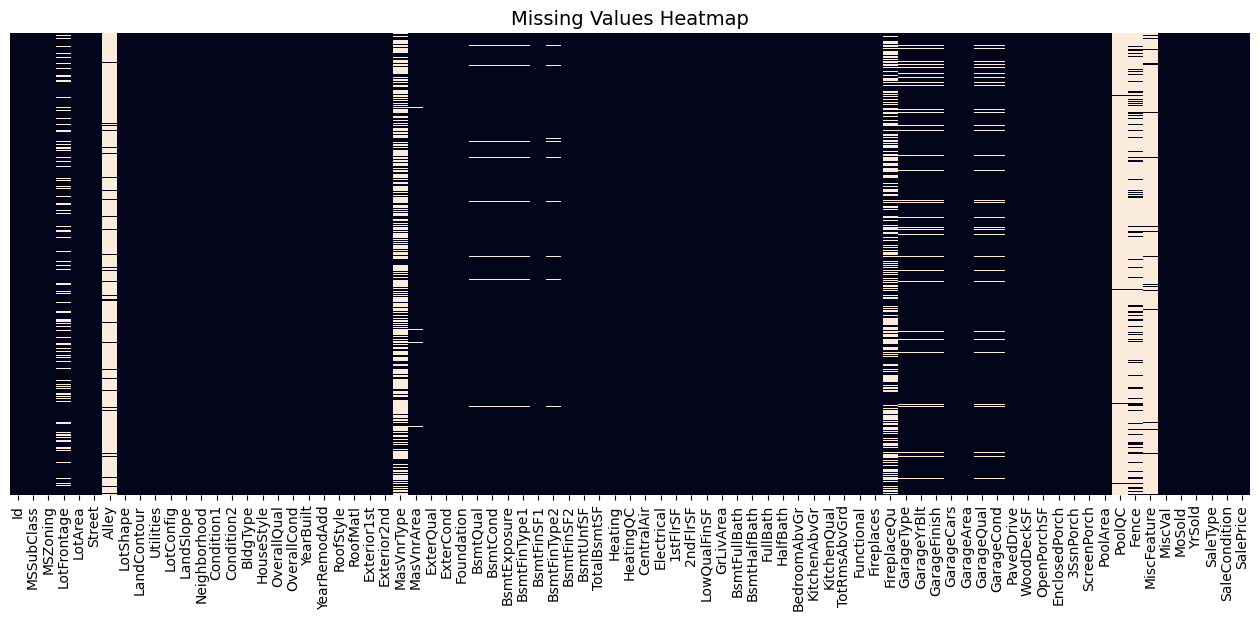

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
sns.heatmap(train_df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap", fontsize=14)
plt.show()

The missingness matrix helps visualize the distribution and pattern of missing values across all features.
It is useful for identifying highly sparse columns, row-wise missing patterns, and whether missing values occur randomly or systematically.

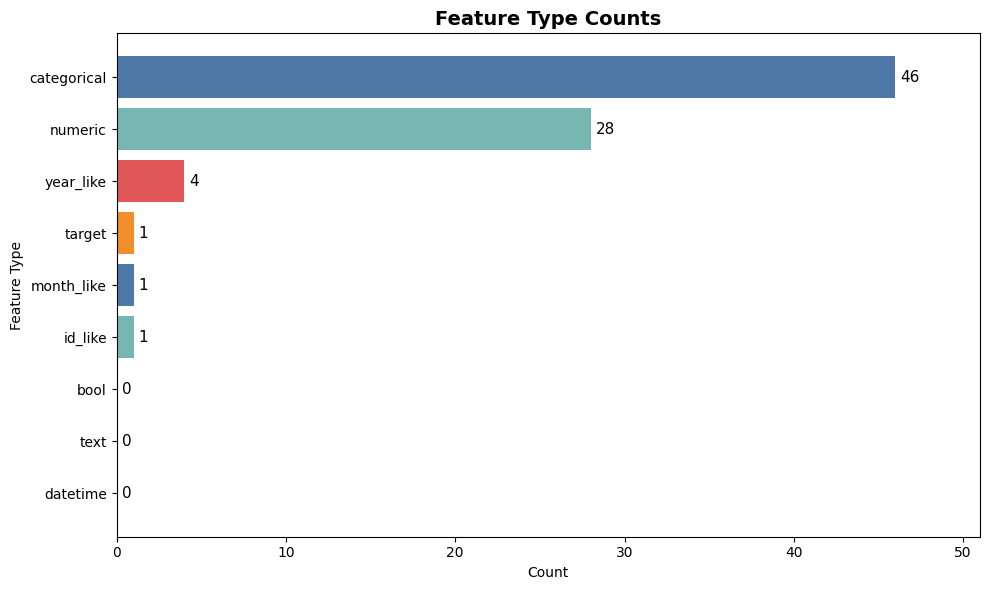

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature type counts from the final corrected report
feature_type_counts = {
    k: len(v)
    for k, v in house_dtype_report.items()
    if k != "object_dtype_columns"
}

feature_type_df = (
    pd.DataFrame(feature_type_counts.items(), columns=["feature_type", "count"])
    .sort_values("count", ascending=True)
)

# Modern Pro palette
colors = ["#4E79A7", "#F28E2C", "#E15759", "#76B7B2", "#4E79A7", "#F28E2C", "#E15759", "#76B7B2"][:len(feature_type_df)]

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_type_df["feature_type"], feature_type_df["count"], color=colors)

plt.title("Feature Type Counts", fontsize=14, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Feature Type")

for bar in bars:
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}",
        va="center",
        fontsize=11
    )

plt.xlim(0, feature_type_df["count"].max() + 5)
plt.tight_layout()
plt.show()

## Basic Dataset Health Report

### Feature Type Summary
After manual correction, the dataset contains **46 categorical/ordinal categorical features**, **28 numerical features**, **4 year-like features**, **1 month-like feature**, **1 ID column**, and **1 target column**.  
There are no direct `datetime`, `text`, or `bool` type columns in the dataset.

### Initial Issues Before EDA
The main issue in this dataset is **missing values**, especially in optional property-related features.  
High-missing columns include `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`, and `FireplaceQu`.

### Issue-Based Feature Notes

| Feature Group | Columns | Issue | Recommended Action |
|---|---|---|---|
| Very high missing | `PoolQC`, `MiscFeature`, `Alley`, `Fence` | 80%+ missing values | Can be removed for a simple baseline model |
| High missing but meaningful | `FireplaceQu` | Missing likely means no fireplace | Fill with `None`, do not remove directly |
| Garage-related | `GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageQual`, `GarageCond` | Same missing count, likely no garage | Fill categorical with `None`, `GarageYrBlt` with `0` or median |
| Basement-related | `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` | Missing likely means no basement | Fill with `None`, keep features |
| Numeric missing | `LotFrontage`, `MasVnrArea` | Numerical missing values | Fill with median or `0` depending on meaning |
| Low missing | `Electrical` | Only 1 missing value | Fill with mode |

### Features We Can Remove for Baseline
For a simple baseline model, we can remove:

`PoolQC`, `MiscFeature`, `Alley`, `Fence`

These features have extremely high missing percentages and may add noise at the beginning.

### Features We Should Not Remove Immediately
Do not remove these directly:

`FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`

Their missing values may carry useful information such as **No Fireplace**, **No Garage**, or **No Basement**.

### Next Recommended Steps
1. Drop only very high-missing low-priority columns for baseline: `PoolQC`, `MiscFeature`, `Alley`, `Fence`.
2. Fill categorical missing values with `"None"` where missing means absence of that feature.
3. Fill numerical missing values using median or meaningful value like `0`.
4. Check target distribution of `SalePrice`.
5. Start univariate and bivariate EDA before model training.

## 2. Target Analysis

In this section, we analyze the target column `SalePrice` before feature-level EDA and model building.  
The goal is to check target health, distribution shape, outliers, percentile ranges, transformation need, and time-related patterns.


### 2.1 Target Health and Statistical Summary

First, we check missing values, data type, descriptive statistics, distribution shape, and important percentile points for `SalePrice`.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

target_col = "SalePrice"
target_series = train_df[target_col].dropna()

# Feature type from house_column_summary
target_feature_type_series = house_column_summary.loc[
    house_column_summary["column"] == target_col,
    "final_corrected_type"
]

target_feature_type = (
    target_feature_type_series.iloc[0]
    if len(target_feature_type_series) > 0
    else "target"
)

# Percentiles
percentile_points = {
    "P01": 0.01,
    "P05": 0.05,
    "P25": 0.25,
    "P50": 0.50,
    "P75": 0.75,
    "P95": 0.95,
    "P99": 0.99
}

percentile_values = {
    p_name: round(target_series.quantile(q), 2)
    for p_name, q in percentile_points.items()
}

# Shape helper functions
def get_skewness_shape(skewness):
    if skewness > 1:
        return "highly right-skewed"
    elif skewness > 0.5:
        return "moderately right-skewed"
    elif skewness < -1:
        return "highly left-skewed"
    elif skewness < -0.5:
        return "moderately left-skewed"
    else:
        return "approximately symmetric"


def get_kurtosis_shape(kurtosis):
    if kurtosis > 1:
        return "leptokurtic / heavy-tailed"
    elif kurtosis < -1:
        return "platykurtic / light-tailed"
    else:
        return "mesokurtic / near-normal tail"


skewness_value = round(target_series.skew(), 3)
kurtosis_value = round(target_series.kurt(), 3)

target_summary_df = pd.DataFrame({
    "target_column": [target_col],
    "feature_type": [target_feature_type],
    "dtype": [target_series.dtype],
    "missing_count": [train_df[target_col].isnull().sum()],
    "missing_percentage": [round(train_df[target_col].isnull().mean() * 100, 2)],
    "min": [target_series.min()],
    "max": [target_series.max()],
    "mean": [round(target_series.mean(), 2)],
    "median": [target_series.median()],
    "mode": [target_series.mode().iloc[0]],
    "std": [round(target_series.std(), 2)],
    "variance": [round(target_series.var(), 2)],
    "range": [target_series.max() - target_series.min()],
    "skewness": [skewness_value],
    "kurtosis": [kurtosis_value],
    "skewness_shape": [get_skewness_shape(skewness_value)],
    "kurtosis_shape": [get_kurtosis_shape(kurtosis_value)],
    **{p_name: [value] for p_name, value in percentile_values.items()}
})

target_summary_df


,target_column,feature_type,dtype,missing_count,missing_percentage,min,max,mean,median,mode,std,variance,range,skewness,kurtosis,skewness_shape,kurtosis_shape,P01,P05,P25,P50,P75,P95,P99
0,SalePrice,target,int64,0,0.0,34900,755000,180921.2,163000.0,140000,79442.5,6.311111e+09,720100,1.883,6.536,highly right-skewed,leptokurtic / heavy-tailed,61815.97,88000.0,129975.0,163000.0,214000.0,326100.0,442567.01


`SalePrice` has no missing values and shows a wide value range. The mean is higher than the median, which indicates a right-skewed target distribution.


### 2.2 Distribution, Normality, and Log Transformation Check

Here we compare the original target with `np.log1p(SalePrice)` using statistics, KDE/histogram, and QQ plots.  
This avoids repeating KDE and QQ plots later in the notebook.


In [15]:
# Original vs log-transformed target
original_target = target_series.copy()
log_target = np.log1p(original_target)

target_transform_comparison = pd.DataFrame({
    "target_version": ["Original SalePrice", "Log1p SalePrice"],
    "mean": [round(original_target.mean(), 3), round(log_target.mean(), 3)],
    "median": [round(original_target.median(), 3), round(log_target.median(), 3)],
    "std": [round(original_target.std(), 3), round(log_target.std(), 3)],
    "skewness": [round(original_target.skew(), 3), round(log_target.skew(), 3)],
    "kurtosis": [round(original_target.kurt(), 3), round(log_target.kurt(), 3)]
})

target_transform_comparison


,target_version,mean,median,std,skewness,kurtosis
0,Original SalePrice,180921.196,163000.000,79442.503,1.883,6.536
1,Log1p SalePrice,12.024,12.002,0.399,0.121,0.810


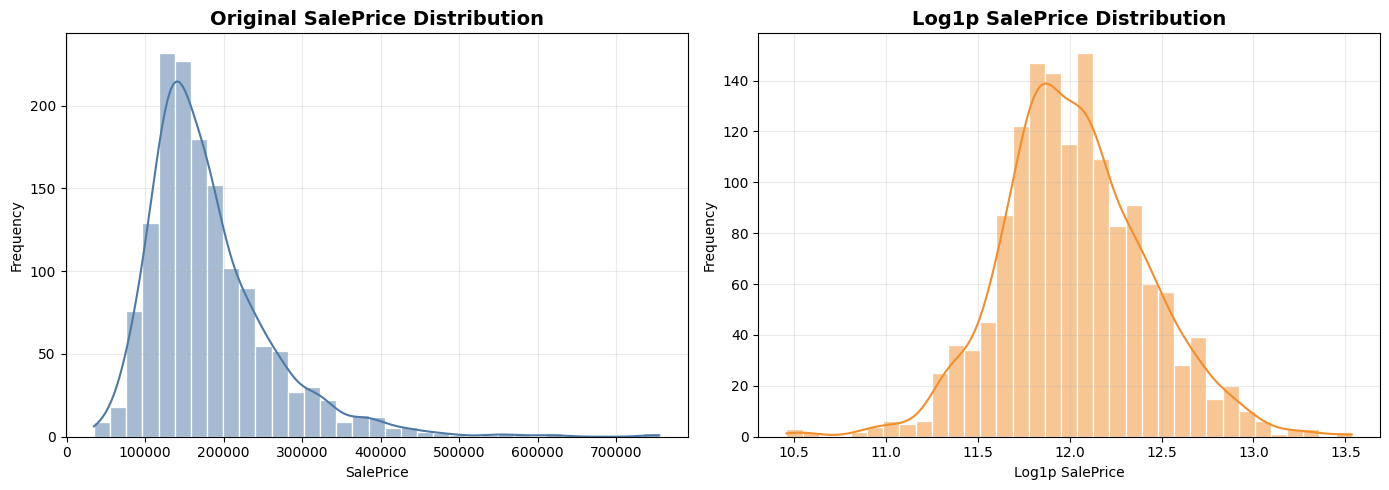

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    original_target,
    kde=True,
    bins=35,
    color="#4E79A7",
    edgecolor="white",
    ax=axes[0]
)
axes[0].set_title("Original SalePrice Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.25)

sns.histplot(
    log_target,
    kde=True,
    bins=35,
    color="#F28E2C",
    edgecolor="white",
    ax=axes[1]
)
axes[1].set_title("Log1p SalePrice Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Log1p SalePrice")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


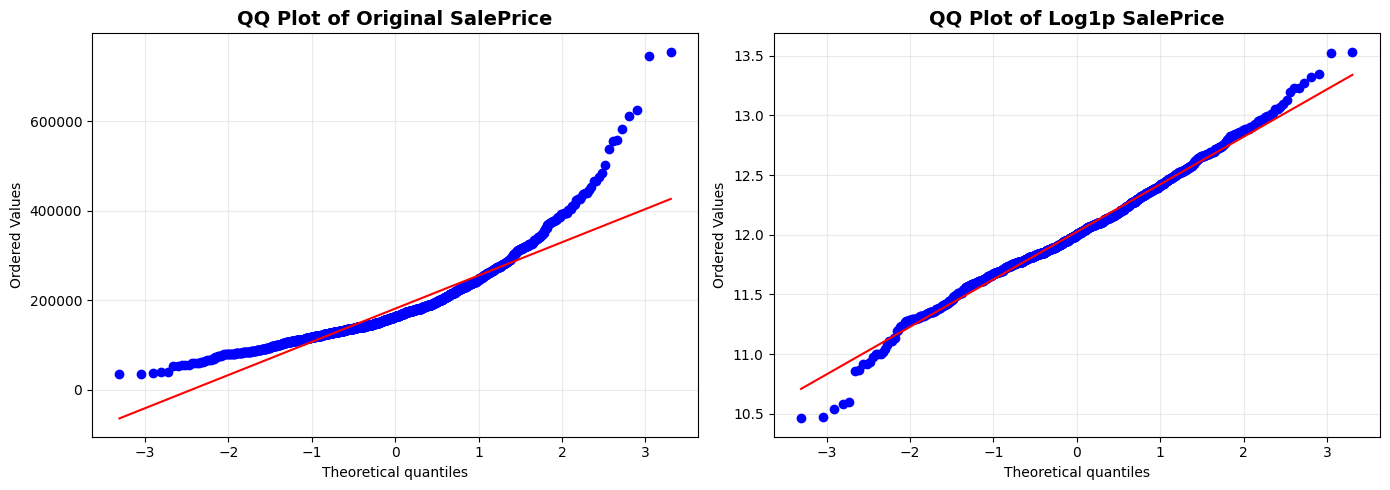

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(original_target, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot of Original SalePrice", fontsize=14, fontweight="bold")
axes[0].grid(alpha=0.25)

stats.probplot(log_target, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot of Log1p SalePrice", fontsize=14, fontweight="bold")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


The original target is highly right-skewed and heavy-tailed, while `np.log1p(SalePrice)` should reduce skewness and improve the QQ plot alignment.  
For modeling, the log-transformed target is likely more stable and model-friendly.


### 2.3 Target Outlier Analysis

Now we detect target outliers using the IQR method, inspect extreme values, and visualize the outlier pattern with box-based plots.


In [18]:
# IQR method
q1 = target_series.quantile(0.25)
q3 = target_series.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (target_series < lower_bound) | (target_series > upper_bound)
outliers = target_series[outlier_mask]

lower_outliers = target_series[target_series < lower_bound].sort_values()
upper_outliers = target_series[target_series > upper_bound].sort_values(ascending=False)

target_outlier_summary_df = pd.DataFrame({
    "target_column": [target_col],
    "method": ["IQR"],
    "q1": [round(q1, 2)],
    "q3": [round(q3, 2)],
    "iqr": [round(iqr, 2)],
    "lower_bound": [round(lower_bound, 2)],
    "upper_bound": [round(upper_bound, 2)],
    "outlier_count": [outliers.shape[0]],
    "outlier_percentage": [round((outliers.shape[0] / len(target_series)) * 100, 2)],
    "lower_outlier_count": [lower_outliers.shape[0]],
    "upper_outlier_count": [upper_outliers.shape[0]],
    "min_outlier_value": [outliers.min() if len(outliers) > 0 else np.nan],
    "max_outlier_value": [outliers.max() if len(outliers) > 0 else np.nan]
})

target_outlier_summary_df


,target_column,method,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage,lower_outlier_count,upper_outlier_count,min_outlier_value,max_outlier_value
0,SalePrice,IQR,129975.0,214000.0,84025.0,3937.5,340037.5,61,4.18,0,61,341000,755000


In [19]:
top_upper_extreme_values = upper_outliers.head(10).reset_index()
top_upper_extreme_values.columns = ["index", "SalePrice"]

top_lower_extreme_values = lower_outliers.head(10).reset_index()
top_lower_extreme_values.columns = ["index", "SalePrice"]

display(top_upper_extreme_values)
display(top_lower_extreme_values)


,index,SalePrice
0,691,755000
1,1182,745000
2,1169,625000
3,898,611657
4,803,582933
5,1046,556581
6,440,555000
7,769,538000
8,178,501837
9,798,485000


,index,SalePrice


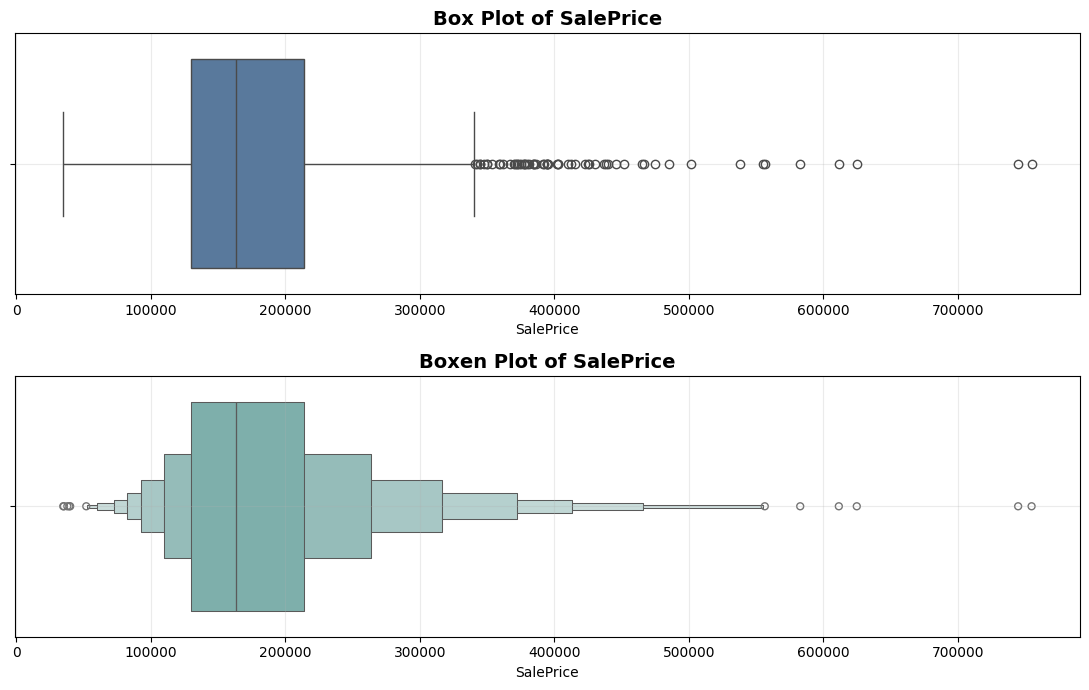

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

sns.boxplot(
    x=target_series,
    color="#4E79A7",
    ax=axes[0]
)
axes[0].set_title("Box Plot of SalePrice", fontsize=14, fontweight="bold")
axes[0].set_xlabel("SalePrice")
axes[0].grid(alpha=0.25)

sns.boxenplot(
    x=target_series,
    color="#76B7B2",
    ax=axes[1]
)
axes[1].set_title("Boxen Plot of SalePrice", fontsize=14, fontweight="bold")
axes[1].set_xlabel("SalePrice")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


`SalePrice` contains upper-side outliers, while lower-side outliers are not present based on the IQR method.  
These expensive houses should not be removed blindly because they may represent valid high-end properties.


### 2.4 High-Price Row Inspection

Before removing target outliers, we inspect high-price rows using important supporting features such as `GrLivArea`, `OverallQual`, `Neighborhood`, and `GarageCars`.


In [21]:
# Use P99 as high-price threshold
high_price_threshold = train_df[target_col].quantile(0.99)

important_outlier_features = [
    "SalePrice",
    "GrLivArea",
    "OverallQual",
    "OverallCond",
    "Neighborhood",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "YearBuilt",
    "YearRemodAdd",
    "FullBath",
    "TotRmsAbvGrd"
]

important_outlier_features = [
    col for col in important_outlier_features
    if col in train_df.columns
]

high_price_rows = (
    train_df.loc[
        train_df[target_col] >= high_price_threshold,
        important_outlier_features
    ]
    .sort_values(by=target_col, ascending=False)
)

high_price_summary_df = pd.DataFrame({
    "threshold_type": ["P99"],
    "high_price_threshold": [round(high_price_threshold, 2)],
    "high_price_row_count": [high_price_rows.shape[0]],
    "high_price_percentage": [round((high_price_rows.shape[0] / len(train_df)) * 100, 2)]
})

display(high_price_summary_df)
high_price_rows


,threshold_type,high_price_threshold,high_price_row_count,high_price_percentage
0,P99,442567.01,15,1.03


,SalePrice,GrLivArea,OverallQual,OverallCond,Neighborhood,GarageCars,GarageArea,TotalBsmtSF,YearBuilt,YearRemodAdd,FullBath,TotRmsAbvGrd
691,755000,4316,10,6,NoRidge,3,832,2444,1994,1995,3,10
1182,745000,4476,10,5,NoRidge,3,813,2396,1996,1996,3,10
1169,625000,3627,10,5,NoRidge,3,807,1930,1995,1996,3,10
898,611657,2364,9,5,NridgHt,3,820,2330,2009,2010,2,11
803,582933,2822,9,5,NridgHt,3,1020,1734,2008,2009,3,12
1046,556581,2868,9,5,StoneBr,3,716,1992,2005,2006,3,11
440,555000,2402,10,5,NridgHt,3,672,3094,2008,2008,2,10
769,538000,3279,8,5,StoneBr,3,841,1650,2003,2003,3,12
178,501837,2234,9,5,StoneBr,3,1166,2216,2008,2009,2,9
798,485000,3140,9,5,NridgHt,3,820,1926,2008,2009,3,11


In [22]:
high_price_rows.describe(include="all")


,SalePrice,GrLivArea,OverallQual,OverallCond,Neighborhood,GarageCars,GarageArea,TotalBsmtSF,YearBuilt,YearRemodAdd,FullBath,TotRmsAbvGrd
count,15.000000,15.000000,15.000000,15.000000,15,15.0,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000
unique,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NridgHt,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,550714.600000,2990.266667,9.466667,5.333333,NaN,3.0,846.733333,2046.800000,1996.60000,2003.866667,2.466667,10.266667
std,99106.121006,743.238999,0.639940,1.046536,NaN,0.0,115.264582,497.040412,29.40311,5.986493,0.516398,1.437591
min,446261.000000,2076.000000,8.000000,5.000000,NaN,3.0,672.000000,1107.000000,1892.00000,1993.000000,2.000000,7.000000
25%,470750.000000,2383.000000,9.000000,5.000000,NaN,3.0,810.000000,1728.000000,1998.50000,1999.000000,2.000000,10.000000
50%,538000.000000,2822.000000,10.000000,5.000000,NaN,3.0,832.000000,1992.000000,2006.00000,2006.000000,2.000000,10.000000
75%,597295.000000,3443.500000,10.000000,5.000000,NaN,3.0,846.000000,2363.000000,2008.00000,2008.500000,3.000000,11.000000


If high-price records have strong supporting features, they should be treated as valid luxury houses rather than abnormal records.  
Outlier removal should only be considered after checking whether the feature values are unrealistic or inconsistent.


### 2.5 Percentile Range Analysis

Percentiles help separate the target into lower, middle, upper, and extreme price ranges.


In [23]:
target_percentiles = pd.DataFrame({
    "percentile": list(percentile_values.keys()),
    "value": list(percentile_values.values())
})

target_percentiles


,percentile,value
0,P01,61815.97
1,P05,88000.00
2,P25,129975.00
3,P50,163000.00
4,P75,214000.00
5,P95,326100.00
6,P99,442567.01


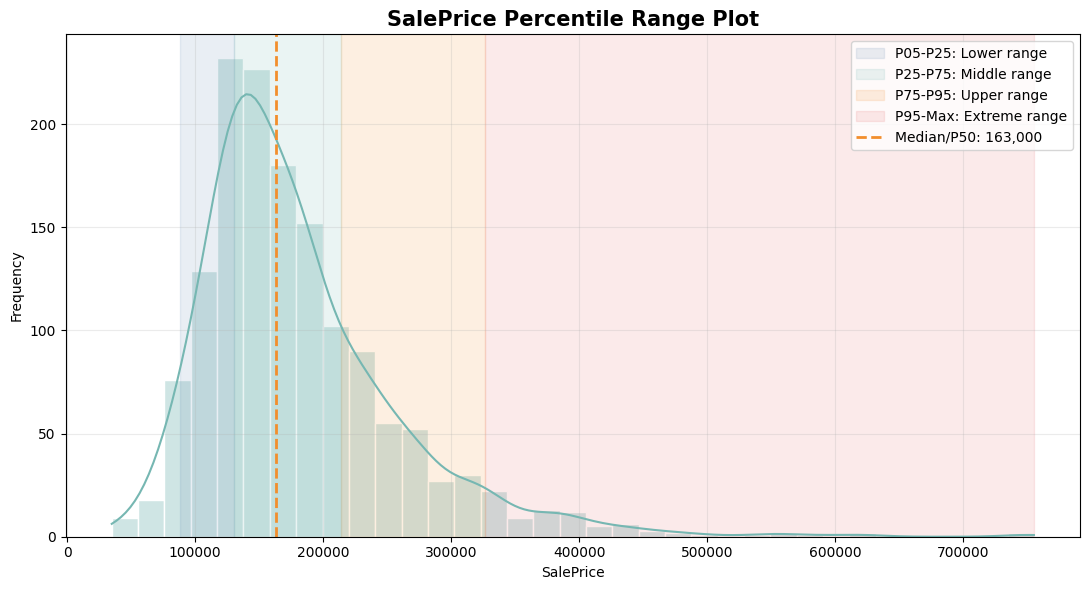

In [24]:
p05 = target_series.quantile(0.05)
p25 = target_series.quantile(0.25)
p50 = target_series.quantile(0.50)
p75 = target_series.quantile(0.75)
p95 = target_series.quantile(0.95)

plt.figure(figsize=(11, 6))

sns.histplot(
    target_series,
    bins=35,
    kde=True,
    color="#76B7B2",
    alpha=0.35,
    edgecolor="white"
)

plt.axvspan(p05, p25, color="#4E79A7", alpha=0.12, label="P05-P25: Lower range")
plt.axvspan(p25, p75, color="#76B7B2", alpha=0.15, label="P25-P75: Middle range")
plt.axvspan(p75, p95, color="#F28E2C", alpha=0.14, label="P75-P95: Upper range")
plt.axvspan(p95, target_series.max(), color="#E15759", alpha=0.12, label="P95-Max: Extreme range")

plt.axvline(
    p50,
    color="#F28E2C",
    linestyle="--",
    linewidth=2,
    label=f"Median/P50: {p50:,.0f}"
)

plt.title("SalePrice Percentile Range Plot", fontsize=15, fontweight="bold")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Most houses are concentrated in the middle percentile range, while values above P95/P99 represent the high-end tail of the distribution.


### 2.6 Target Trend Over Time

Here we analyze sale activity and price trend separately, because more sales in a month does not necessarily mean higher prices.


In [25]:
target_time_df = train_df[["YrSold", "MoSold", target_col]].copy()

target_time_df["SaleDate"] = pd.to_datetime({
    "year": target_time_df["YrSold"],
    "month": target_time_df["MoSold"],
    "day": 1
})

monthly_target_trend = (
    target_time_df
    .groupby("SaleDate")
    .agg(
        sale_count=(target_col, "count"),
        mean_sale_price=(target_col, "mean"),
        median_sale_price=(target_col, "median")
    )
    .reset_index()
)

yearly_target_trend = (
    target_time_df
    .groupby("YrSold")
    .agg(
        sale_count=(target_col, "count"),
        mean_sale_price=(target_col, "mean"),
        median_sale_price=(target_col, "median")
    )
    .reset_index()
)

display(monthly_target_trend.head())
yearly_target_trend


,SaleDate,sale_count,mean_sale_price,median_sale_price
0,2006-01-01,10,201090.000000,176700.0
1,2006-02-01,9,194322.222222,192500.0
2,2006-03-01,25,184982.200000,162900.0
3,2006-04-01,27,174312.814815,145250.0
4,2006-05-01,38,158928.289474,156950.0


,YrSold,sale_count,mean_sale_price,median_sale_price
0,2006,314,182549.458599,163995.0
1,2007,329,186063.151976,167000.0
2,2008,304,177360.838816,164000.0
3,2009,338,179432.103550,162000.0
4,2010,175,177393.674286,155000.0


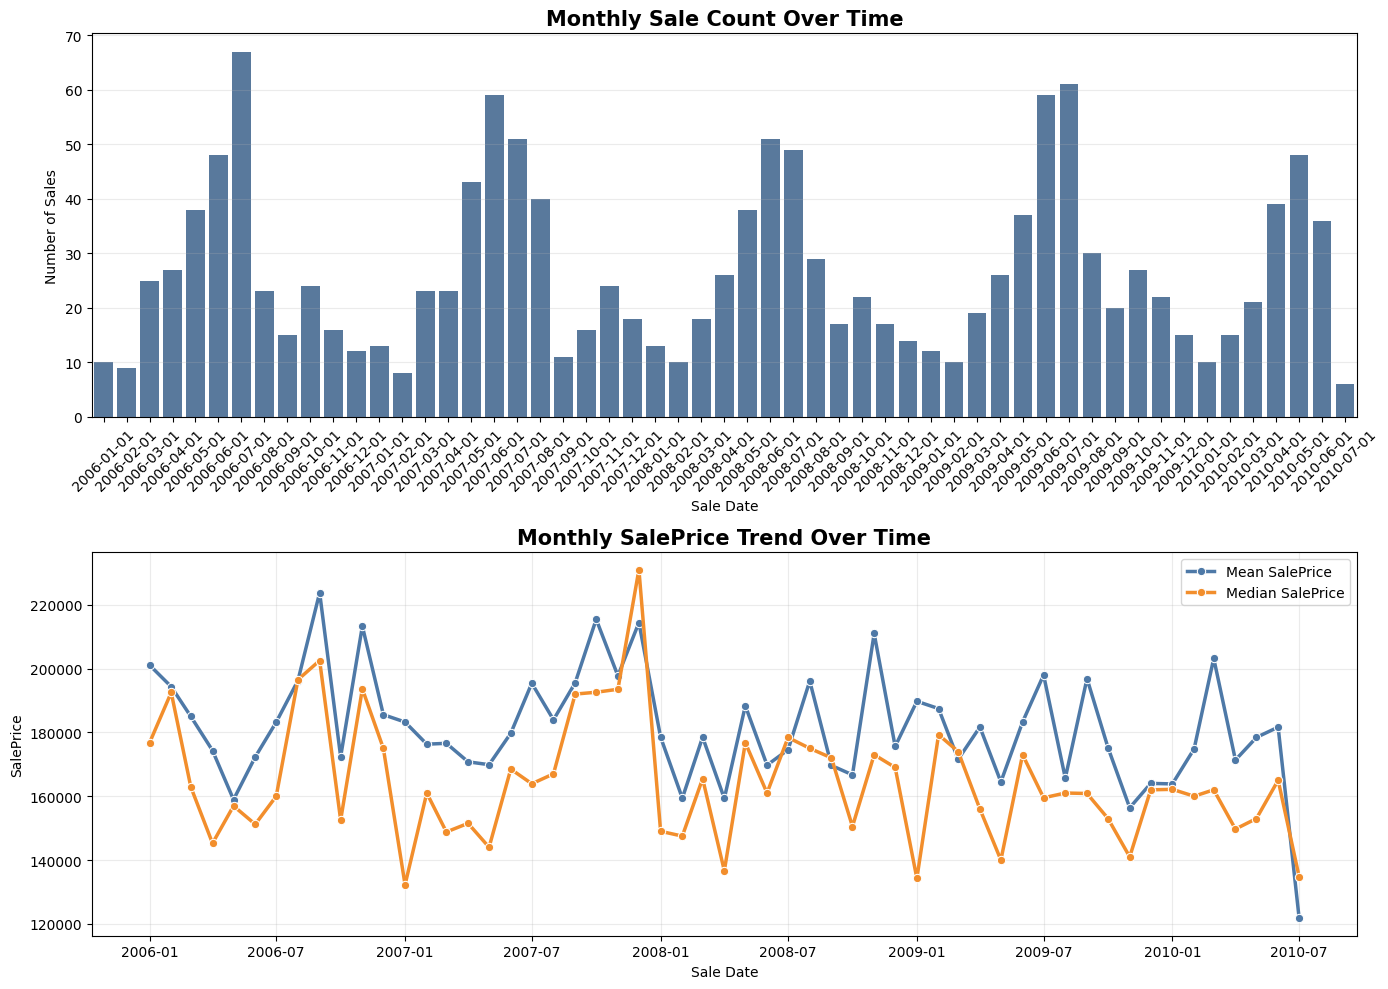

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

sns.barplot(
    data=monthly_target_trend,
    x="SaleDate",
    y="sale_count",
    color="#4E79A7",
    ax=axes[0]
)
axes[0].set_title("Monthly Sale Count Over Time", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Sale Date")
axes[0].set_ylabel("Number of Sales")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.25)

sns.lineplot(
    data=monthly_target_trend,
    x="SaleDate",
    y="mean_sale_price",
    marker="o",
    linewidth=2.5,
    color="#4E79A7",
    label="Mean SalePrice",
    ax=axes[1]
)

sns.lineplot(
    data=monthly_target_trend,
    x="SaleDate",
    y="median_sale_price",
    marker="o",
    linewidth=2.5,
    color="#F28E2C",
    label="Median SalePrice",
    ax=axes[1]
)

axes[1].set_title("Monthly SalePrice Trend Over Time", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Sale Date")
axes[1].set_ylabel("SalePrice")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


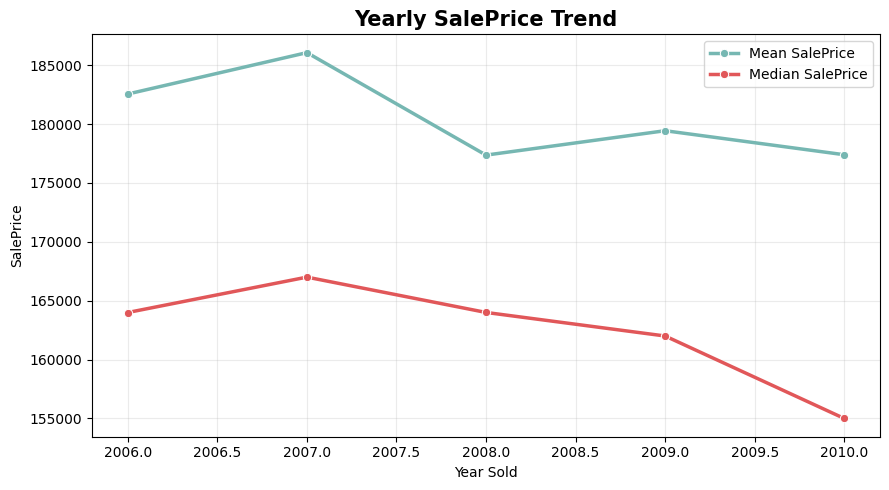

In [27]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=yearly_target_trend,
    x="YrSold",
    y="mean_sale_price",
    marker="o",
    linewidth=2.5,
    color="#76B7B2",
    label="Mean SalePrice"
)

sns.lineplot(
    data=yearly_target_trend,
    x="YrSold",
    y="median_sale_price",
    marker="o",
    linewidth=2.5,
    color="#E15759",
    label="Median SalePrice"
)

plt.title("Yearly SalePrice Trend", fontsize=15, fontweight="bold")
plt.xlabel("Year Sold")
plt.ylabel("SalePrice")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


Mid-year months show higher sale activity, while winter months show lower activity, suggesting a seasonal transaction pattern.  
However, sale count and price trend are different signals: higher transaction volume does not directly mean higher house prices.


### 2.7 Final Target Analysis Decision

`SalePrice` is clean with no missing values, but it is highly right-skewed, heavy-tailed, and contains upper-side outliers.  
For modeling, `np.log1p(SalePrice)` should be considered, and high-price rows should be inspected carefully before removing any target outliers.


In [28]:
# Optional: create transformed target for modeling
train_df["SalePrice_log"] = np.log1p(train_df["SalePrice"])

# For inverse transformation after prediction:
# original_scale_prediction = np.expm1(log_scale_prediction)
